# Mô hình Nâng cao: XGBoost & Feature Engineering
Trong phần này, chúng ta sẽ sử dụng toàn bộ dữ liệu (tất cả 3 thành phố, dữ liệu theo giờ) để huấn luyện mô hình XGBoost.

**Feature Engineering**:
XGBoost có khả năng học các mối quan hệ phi tuyến tính rất tốt. Chúng ta sẽ đưa vào tất cả các feature đã được tính toán trong bước xử lý dữ liệu trước đó, bao gồm:
- **Lag features**: Lịch sử nồng độ PM2.5 trong các giờ trước đó (giúp mô hình biết được xu hướng gần nhất).
- **Rolling features**: Nồng độ PM2.5 trung bình trong các khung cửa sổ thời gian (giúp làm mượt dữ liệu và bỏ nhiễu).
- **Thời tiết và không gian**: Đặc điểm khí tượng và khoảng cách đến các nhà máy gây ô nhiễm.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Đọc dữ liệu đã qua tiền xử lý
df = pd.read_csv('../data/processed/pm25_training_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values(['city', 'datetime']).reset_index(drop=True)

# Danh sách features cho XGBoost
FEATURES = [
    'temp', 'humidity', 'wind_speed', 'wind_dir', 'precip', 'pressure', 'cloud_cover',
    'pm10', 'o3', 'no2', 'so2', 'co',
    'factories_2km', 'factories_5km',
    'hour', 'day_of_week', 'month', 'is_weekend', 'day_of_year',
    'pm25_lag_1h', 'pm25_lag_3h', 'pm25_lag_6h', 'pm25_lag_12h', 'pm25_lag_24h',
    'pm25_roll_6h', 'pm25_roll_24h', 'pm25_roll_72h'
]
df['target_24h'] = df.groupby('city')['pm25'].shift(-24)
TARGET = 'target_24h'

# Bỏ các dòng có giá trị rỗng ở lag features (những giờ đầu tiên không có lịch sử)
df_model = df.dropna(subset=FEATURES + [TARGET]).copy()

print(f"Tổng số mẫu sau khi làm sạch: {len(df_model):,}")
print(f"Số lượng features: {len(FEATURES)}")

Tổng số mẫu sau khi làm sạch: 98,763
Số lượng features: 27


## Chia tập Train/Val/Test theo thời gian
Tương tự như SARIMAX, chúng ta không chia dữ liệu ngẫu nhiên để tránh rò rỉ dữ liệu (Data Leakage).

In [2]:
# Cắt tập Train/Val/Test theo tỷ lệ 70/15/15 theo thời gian
train_cutoff = df_model['datetime'].quantile(0.70)
val_cutoff   = df_model['datetime'].quantile(0.85)

train_mask = df_model['datetime'] <= train_cutoff
val_mask   = (df_model['datetime'] > train_cutoff) & (df_model['datetime'] <= val_cutoff)
test_mask  = df_model['datetime'] > val_cutoff

X_train = df_model.loc[train_mask, FEATURES]
y_train = df_model.loc[train_mask, TARGET]
X_val   = df_model.loc[val_mask,   FEATURES]
y_val   = df_model.loc[val_mask,   TARGET]
X_test  = df_model.loc[test_mask,  FEATURES]
y_test  = df_model.loc[test_mask,  TARGET]

print(f"Số lượng mẫu Train: {len(X_train):,}")
print(f"Số lượng mẫu Val:   {len(X_val):,}")
print(f"Số lượng mẫu Test:  {len(X_test):,}")

Số lượng mẫu Train: 69,135
Số lượng mẫu Val:   14,814
Số lượng mẫu Test:  14,814


## Huấn luyện XGBoost với Early Stopping
XGBoost có một kỹ thuật rất tốt là Early Stopping: Nếu độ lỗi trên tập Test không giảm sau N lượt (epochs), nó sẽ dừng sớm để chống Overfitting.

In [3]:
# Thiết lập tham số (Hyperparameters) cho XGBoost
xgb_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 30
}

model_xgb = xgb.XGBRegressor(**xgb_params)

# Huấn luyện mô hình
print("Bắt đầu huấn luyện XGBoost...")
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

# Dự đoán
y_pred = model_xgb.predict(X_test)

# Đánh giá
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f"\n📊 KẾT QUẢ XGBoost:")
print(f"   RMSE: {rmse:.2f} µg/m³")
print(f"   MAE:  {mae:.2f} µg/m³")

Bắt đầu huấn luyện XGBoost...
[0]	validation_0-rmse:19.68463	validation_1-rmse:25.40084
[50]	validation_0-rmse:12.41555	validation_1-rmse:19.71784
[100]	validation_0-rmse:11.32305	validation_1-rmse:19.59165
[101]	validation_0-rmse:11.31265	validation_1-rmse:19.59197

📊 KẾT QUẢ XGBoost:
   RMSE: 16.70 µg/m³
   MAE:  10.29 µg/m³


## Tầm quan trọng của các biến (Feature Importance)
Hãy cùng xem mô hình XGBoost đánh giá tính năng nào đóng góp nhiều nhất vào việc dự báo. Rất có thể các đặc trưng quá khứ (Lag) sẽ đứng top đầu.

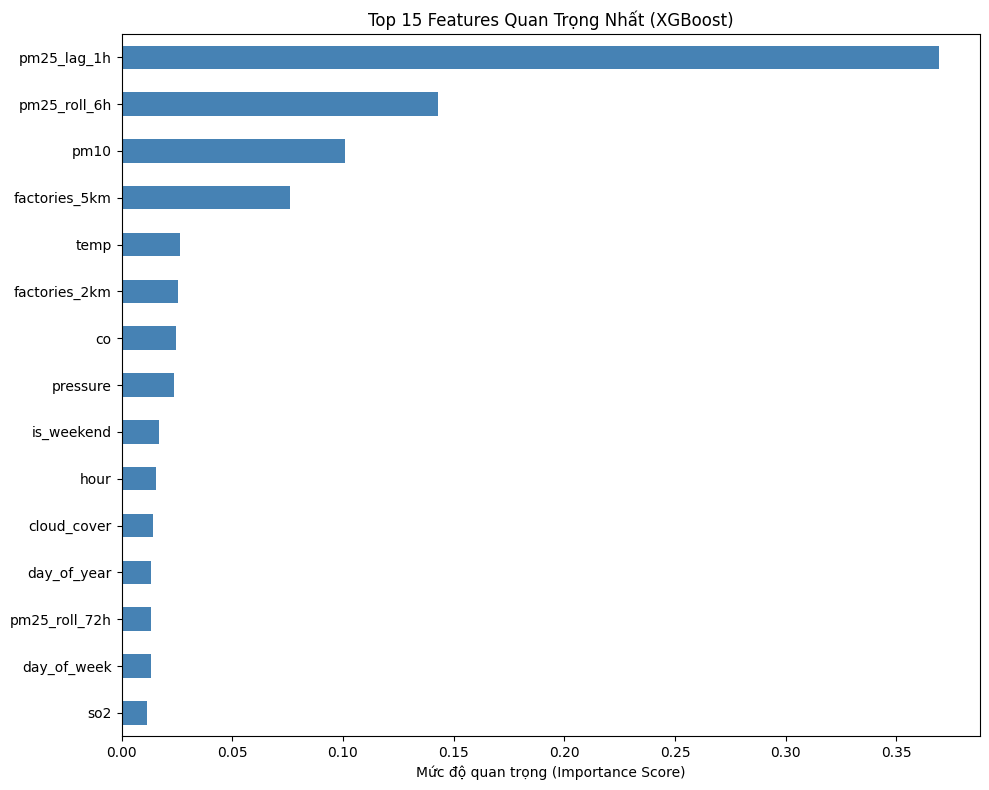

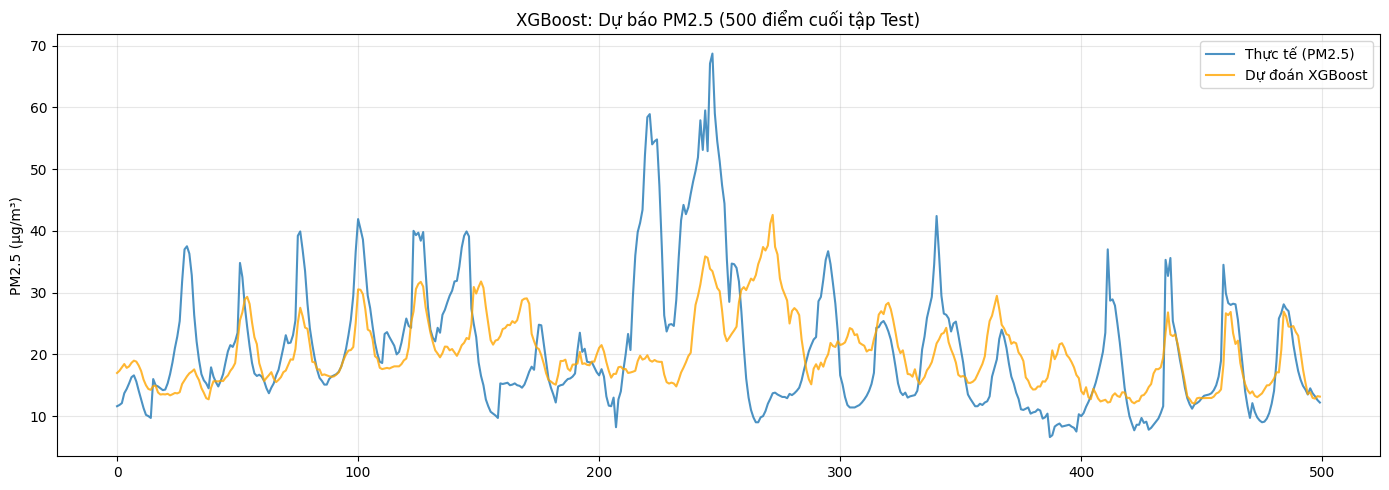

In [4]:
# Vẽ biểu đồ Feature Importance
feat_importance = pd.Series(
    model_xgb.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_importance.tail(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Features Quan Trọng Nhất (XGBoost)')
plt.xlabel('Mức độ quan trọng (Importance Score)')
plt.tight_layout()
plt.show()

# Trực quan hóa dự báo (lấy 500 điểm dữ liệu cuối cùng cho rõ)
n_show = min(500, len(y_test))
plt.figure(figsize=(14, 5))
plt.plot(range(n_show), y_test.values[-n_show:], label='Thực tế (PM2.5)', alpha=0.8)
plt.plot(range(n_show), y_pred[-n_show:], color='orange', label='Dự đoán XGBoost', alpha=0.8)
plt.title(f'XGBoost: Dự báo PM2.5 ({n_show} điểm cuối tập Test)')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()